# **Matriz Admitancia Indefinida**

## **Trabajo Semanal 5**

### Autor: Keila Korj
### Profesor: Mariano Llamedo Soria
### Ayudante de TPs: David Moharos



# ***Introducción***

En el siguiente trabajo se realizará la adquisición de la MAI (Matriz Admitancia Indefinida) de los cicuitos presentados en la figura.

<div align="center">
  <figure>
    <img src="./imagenes_ts5/circs_consigna.png" width="600" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 1: Circuito 1- Red T/Circuito 2- BS170
    </figcaption>
  </figure>
</div>

Además se obtendrán transferencias de tensión del circuito 1 en conjunto con la implmentación de *Python* para verificar. Y finalmente se obtendrán los *parámetros y* del circuito 2 en source y drain común, añadiento simulaciones circuitales para el segundo caso.

# ***Construcción de la MAI***

## ***Circuito 1: Red T***

Para facilitar el procedimineto se decidió añadir un nodo interno llamado *nodo 4* que se comprende entre los inductores y el capacitor.

<div align="center">
  <figure>
    <img src="./imagenes_ts5/circ1.png" width="400" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 2: Red T con nodo interno
    </figcaption>
  </figure>
</div>

Tal que por inspección se logró:

$$
\begin{bmatrix}
Y_{{MAI1}}
\end{bmatrix}=
\begin{bmatrix}
Y_L & 0 & 0 & -Y_L \\
0 & Y_l & 0 & -Y_L \\
0 & 0  & Y_C & -Y_C \\
-Y_L & -Y_L & -Y_C & 2Y_L + Y_C 
\end{bmatrix}
$$

Donde:

$$ Y_L = \frac{1}{sL} $$
$$ Y_C = sC$$

Sin embargo, aquí se tiene una matriz de 4x4 y lo que se intenta buscar es una de 3x3 correspondiente a los nodos brindados en la *Figura 1*. Para ello se realiza la supresión de la fila y columna 4, de modo que se divide la $Y_{MAI1}$ en:

$$
\begin{bmatrix}
Y_{{11}}
\end{bmatrix} =
\begin{bmatrix}
Y_L & 0 & 0 \\
0 & Y_L & 0 \\
0 & 0 & Y_C
\end{bmatrix}
$$

$$
\begin{bmatrix}
Y_{{12}} 
\end{bmatrix}=
\begin{bmatrix}
-Y_L \\
-Y_L \\
-Y_C
\end{bmatrix}
$$

$$
\begin{bmatrix}
Y_{{21}}
\end{bmatrix}=
\begin{bmatrix}
-Y_L & -Y_L & -Y_C
\end{bmatrix}
$$

$$
\begin{bmatrix}
Y_{{22}}
\end{bmatrix}^{-1}=
\begin{bmatrix}
\frac{1}{ 2Y_L + Y_C}
\end{bmatrix}
$$

Dado que la matriz buscada se encuentra realizando el siguiente cálculo:

$$
\begin{bmatrix}
Y_{{MAI1}}
\end{bmatrix}=
\begin{bmatrix}
Y_{{11}}
\end{bmatrix} \space - \space
\begin{bmatrix}
Y_{{12}} 
\end{bmatrix} \cdot
\begin{bmatrix}
Y_{{22}}
\end{bmatrix}^{-1} \cdot
\begin{bmatrix}
Y_{{21}}
\end{bmatrix}
$$

Por lo tanto, 

$$
\begin{bmatrix}
Y_{{MAI1}}
\end{bmatrix}=
\frac{1}{2Y_L + Y_C} \cdot
\begin{bmatrix}
Y_L^{2} + Y_L\cdot Y_C & -Y_L^{2} & -Y_L\cdot Y_C \\
-Y_L^{2} & Y_L^{2} + Y_L \cdot Y_C & -Y_L\cdot Y_C \\
-Y_L\cdot Y_C & -Y_L\cdot Y_C & 2Y_L\cdot Y_C
\end{bmatrix}
$$

Reemplazando valores, queda finalmente:

$$
\begin{bmatrix}
Y_{{MAI1}}
\end{bmatrix}=
\frac{1}{2\cdot \frac{1}{sL} + sC} \cdot
\begin{bmatrix}
\frac{1}{sL}\cdot (\frac{1}{sL} + sC) & -(\frac{1}{sL})^{2} & -\frac{C}{L} \\
-(\frac{1}{sL})^{2} & \frac{1}{sL}\cdot (\frac{1}{sL} + sC) & -\frac{C}{L} \\
-\frac{C}{L} & -\frac{C}{L} & 2\frac{C}{L}
\end{bmatrix}
$$

## ***Transistor NMOS BS170***

Para obtener la MAI en este caso observando la *Figura 1* no es suficiente puesto que no tenemos toda la información necesaria para hallarla. Es por eso que se recurre a su circuito equivalente presente en la *Figura 3*.

<div align="center">
  <figure>
    <img src="./imagenes_ts5/circ2.png" width="600" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 3: NMOS circuito equivalente
    </figcaption>
  </figure>
</div>

Por ende ya sea por inspección o sabiendo que:

$$
i_1 = Y_{gs}\cdot V_{gs} + Y_{gd}\cdot V_{gd} 
$$
$$
i_2 = Y_{ds}\cdot V_{ds} + Y_{gd}\cdot V_{dg} + gm\cdot V_{gs}
$$
$$
i_3 = Y_{ds}\cdot V_{ds} + Y_{gs}\cdot V_{sg} + gm\cdot V_{sg}
$$

Donde:
$$
V_{gs} = V_g - V_s = -V_{sg}
$$
$$
V_{gd} = V_g - V_d = -V_{dg}
$$
$$
V_{ds} = V_d - V_s = -V_{sd}
$$

Se obtiene:

$$
\begin{bmatrix}
Y_{{MAI2}} 
\end{bmatrix}=
\begin{bmatrix}
Y_{gs} + Y_{gd} & -Y_{gd} & -V_{gs} \\
gm -Y_{gd} & Y_{ds} + Y_{gd} & -gm - Y_{ds} \\
-gm -Y_{gs} & -Y_{ds} & Y_{gs} + Y_{ds} + gm 
\end{bmatrix}
$$

Siendo:

$$ Y_{gs} = s\cdot C_{gs}$$ $$ Y_{gd} = s\cdot C_{gd} $$ $$ Y_{ds} = s\cdot C_{ds}$$

Queda finalmente:

$$
\begin{bmatrix}
Y_{{MAI2}} 
\end{bmatrix}=
\begin{bmatrix}
s\cdot (C_{gs} + C_{gd}) & -s\cdot C_{gd} & -s\cdot C_{gs} \\
gm - s\cdot C_{gd}  & s\cdot (C_{ds} + C_{gd}) & -(s\cdot C_{ds} + gm) \\
-(gm + s\cdot C_{gs}) & -s\cdot C_{ds} & gm + s\cdot (C_{gs} + C_{ds})
\end{bmatrix}
$$

Pero si tenemos en cuenta a $C_{iss}$, $C_{oss}$ y $C_{rss}$, donde:

$$ C_{rss} = C_{gd}$$
$$ C_{iss} = C_{gd} + C_{gs}$$
$$ C_{oss} = C_{gd} + C_{ds}$$

Se obtiene que:

$$ C_{gs} = C_{iss} - C_{rss}$$
$$ C_{ds} = C_{oss} - C_{rss}$$

Con lo cual, como último paso se reemplaza, adquiriendo:


$$
\begin{bmatrix}
Y_{{MAI2}} 
\end{bmatrix}=
\begin{bmatrix}
s\cdot C_{iss} & -s\cdot C_{rss} & -s\cdot (C_{iss} - C_{rss}) \\
gm - s\cdot C_{rss} & s\cdot C_{oss} & -[gm + s\cdot (C_{oss} - C_{rss})] \\
-[gm + s\cdot (C_{oss} - C_{rss})] & -s\cdot (C_{oss} - C_{rss})] & gm + s\cdot (C_{iss} +C_{oss} - 2C_{rss})
\end{bmatrix}
$$

# ***Transferencias de tensión de la Red T***

Para hallar las distintas transferencias de tensión es necesario emplear el siguiente cálculo:

$$ A^{ij}_{mn} = sgn(i-j) \cdot sgn(m-n) \cdot \frac{\underline{Y}^{mn}_{ij}}{\underline{Y}^{mn}_{mn}}$$

Donde: $$\underline{Y}^{ab}_{dc} = (-1)^{i+j+m+n}\cdot M^{ab}_{cd}$$

## ***Transferencia V23/V13***

$$ A^{23}_{13} = sgn(2-3) \cdot sgn(1-3) \cdot \frac{\underline{Y}^{13}_{23}}{\underline{Y}^{13}_{13}}$$

Siendo:
$$\underline{Y}^{13}_{23} = (-1)^{9} \cdot -\frac{1}{(sL)^{2}} \cdot \frac{1}{\frac{2}{sL} + sC}$$

Y:
$$\underline{Y}^{13}_{13} = (-1)^{8} \cdot \frac{1}{sL} \cdot (\frac{1}{sL} + sC) \cdot \frac{1}{\frac{2}{sL} + sC}$$

De modo tal que la transferencia final queda:

$$A^{23}_{13} = \frac{\frac{1}{CL}}{s^{2} + \frac{1}{CL}}$$

Que corresponde con un *pasa bajos de segundo orden*, con la caraterística de tener un Q que tiende al infinito. A continuación se grafica su módulo y fase.

(1,
 array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
        <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
       dtype=object))

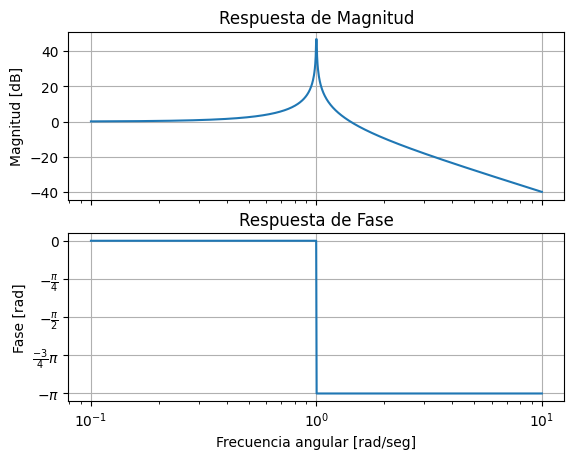

In [9]:
import numpy as np
#import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq

#Normalizo el valor de los componentes
C = 1 
L = 1

#TRANSFERENCIA V23/V13:

num = np.array([ 1/(C*L) ])
den = np.array([ 1, 0, 1/(C*L) ])

H1 = sig.TransferFunction( num, den )

# Otra forma de analizar el sistema H1, con una función
# de más alto nivel. Podés probarlo si te interesa.

# el caracter "_" descarta la salida de la función
bodePlot(H1, 'TRANSFERENCIA V23/V13')

Comprobando gráficamente el elevado Q que presenta la transferencia con el abrupto realce del módulo en la frecuencia de resonancia y el brusco cambión de fase en la misma.

## ***Transferencia V21/V31***

$$ A^{21}_{31} = sgn(2-1) \cdot sgn(3-1) \cdot \frac{\underline{Y}^{31}_{21}}{\underline{Y}^{31}_{31}}$$

Siendo:
$$\underline{Y}^{31}_{21} = (-1)^{7} \cdot -\frac{C}{L} \cdot \frac{1}{\frac{2}{sL} + sC}$$

Y:
$$\underline{Y}^{31}_{31} = (-1)^{8} \cdot \frac{1}{sL} \cdot (\frac{1}{sL} + sC) \cdot \frac{1}{\frac{2}{sL} + sC}$$

De modo tal que la transferencia final queda:

$$A^{21}_{31} = \frac{s^{2}}{s^{2} + \frac{1}{CL}}$$

Que corresponde con un *pasa altos de segundo orden*, con la caraterística de tener un Q que tiende al infinito.. A continuación se grafica su módulo y fase.

(1,
 array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
        <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
       dtype=object))

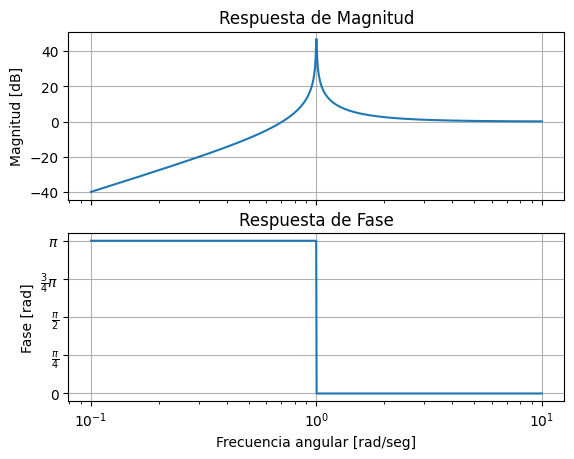

In [10]:
import numpy as np
#import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq

#Normalizo el valor de los componentes
C = 1 
L = 1

#TRANSFERENCIA V21/V31:


num = np.array([ 1, 0, 0 ])
den = np.array([ 1, 0, 1/(C*L) ])

H1 = sig.TransferFunction( num, den )

# Otra forma de analizar el sistema H1, con una función
# de más alto nivel. Podés probarlo si te interesa.

# el caracter "_" descarta la salida de la función

bodePlot(H1, 'TRANSFERENCIA V21/V31')


Comprobando gráficamente el elevado Q que presenta la transferencia con el abrupto realce del módulo en la frecuencia de resonancia y el brusco cambión de fase en la misma.

## ***Transferencia V12/V32***

$$ A^{12}_{32} = sgn(1-2) \cdot sgn(3-2) \cdot \frac{\underline{Y}^{32}_{12}}{\underline{Y}^{32}_{32}}$$

Siendo:
$$\underline{Y}^{32}_{12} = (-1)^{8} \cdot -\frac{C}{L} \cdot \frac{1}{\frac{2}{sL} + sC}$$

Y:
$$\underline{Y}^{32}_{32} = (-1)^{10} \cdot \frac{1}{sL} \cdot (\frac{1}{sL} + sC) \cdot \frac{1}{\frac{2}{sL} + sC}$$

De modo tal que la transferencia final queda:

$$A^{12}_{32} = \frac{s^{2}}{s^{2} + \frac{1}{CL}}$$

Que corresponde con un *pasa altos de segundo orden*, con la caraterística de tener un Q que tiende al infinito.. A continuación se grafica su módulo y fase.

(1,
 array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
        <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
       dtype=object))

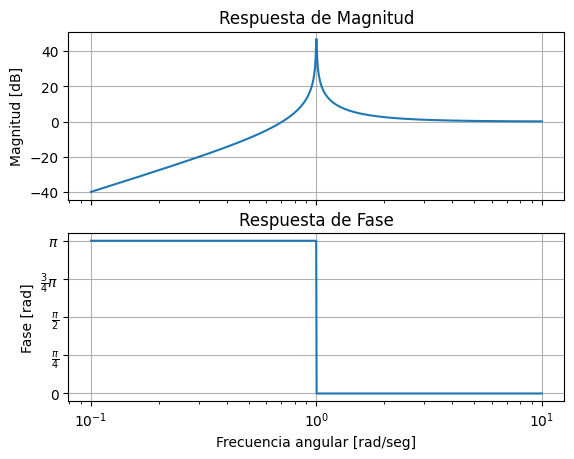

In [12]:
import numpy as np
#import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq

#Normalizo el valor de los componentes
C = 1 
L = 1

#TRANSFERENCIA V12/V32:


num = np.array([ 1, 0, 0 ])
den = np.array([ 1, 0, 1/(C*L) ])

H1 = sig.TransferFunction( num, den )

# Otra forma de analizar el sistema H1, con una función
# de más alto nivel. Podés probarlo si te interesa.

# el caracter "_" descarta la salida de la función

bodePlot(H1, 'TRANSFERENCIA V12/V32')


Comprobando gráficamente el elevado Q que presenta la transferencia con el abrupto realce del módulo en la frecuencia de resonancia y el brusco cambión de fase en la misma.

## *Complementariedad de módulo*

Por observación de las transferencias es notorio que existe complementariedad en módulo entre cualquiera de los pasa altos obtenidos con el primer pasabajos adquirido. Dado que al sumar:

$$ \frac{\frac{1}{CL}}{s^{2} + \frac{1}{CL}} + \frac{s^{2}}{s^{2} + \frac{1}{CL}} = \frac{s^{2} + \frac{1}{CL}}{s^{2} + \frac{1}{CL}} = 1 $$

# ***Parámetros Y para el MOS en las configuraciones Source Común y Drain Común***

Como ya se ha calculado la MAI del transistor MOS basta simplmente con aterrizar el nodo correspondiente para conseguir los *parámetros Y* de cualquier configuración. Recordando la MAI del NMOS:

$$
\begin{bmatrix}
Y_{{MAI_{MOS}}} 
\end{bmatrix}=
\begin{bmatrix}
s\cdot C_{iss} & -s\cdot C_{rss} & -s\cdot (C_{iss} - C_{rss}) \\
gm - s\cdot C_{rss} & s\cdot C_{oss} & -[gm + s\cdot (C_{oss} - C_{rss})] \\
-[gm + s\cdot (C_{oss} - C_{rss})] & -s\cdot (C_{oss} - C_{rss})] & gm + s\cdot (C_{iss} +C_{oss} - 2C_{rss})
\end{bmatrix}
$$

## ***Source Común***

En este caso como el *nodo 3* es el correspondiente al *source*, será necesario eliminar la fila y columna 3 de la MAI para lograr el objetivo buscado. Con lo cual: 

$$
\begin{bmatrix}
Y_{{SC}}
\end{bmatrix}=
\begin{bmatrix}
s\cdot C_{iss} & -s\cdot C_{rss} \\
gm - s\cdot C_{rss} & s\cdot C_{oss}
\end{bmatrix}
$$

## ***Drain Común***

En este caso como el *nodo 2* es el correspondiente al *source*, será necesario eliminar la fila y columna 2 de la MAI para lograr el objetivo buscado. Con lo cual: 

$$
\begin{bmatrix}
Y_{{DC}}
\end{bmatrix}=
\begin{bmatrix}
s\cdot C_{iss} & -s\cdot (C_{iss} - C_{rss}) \\
-[gm - s\cdot (C_{iss}-C_{rss})] & gm + s\cdot (C_{iss} + C_{oss} - 2C_{rss})
\end{bmatrix}
$$

# ***Matriz de parámetros ABCD en configuración Source Común***

Para ellos es necesario aplicar la transformación entre *parámetro Y* a *paramentro ABCD*, siendo esta:

$$
\begin{bmatrix}
T_{ABCD}
\end{bmatrix}= -\frac{1}{Y_{21}}
\begin{bmatrix}
Y_{22} & 1 \\
\Delta{Y} & Y_{11}
\end{bmatrix}
$$

Siendo en este caso:

$$Y_{11} = s\cdot C_{iss}$$ $$Y_{12} = -s\cdot C_{rss} $$ $$Y_{21} = gm - s\cdot C_{rss}$$ $$ Y_{22} = s\cdot C_{oss}$$
$$\Delta{Y} = s^{2}\cdot (C_{iss} C_{oss} - C_{rss}^{2}) + s\cdot gm \cdot C_{rss}$$

Quedando la matriz:

$$
\begin{bmatrix}
T_{{SC}}
\end{bmatrix}= -\frac{1}{gm - s\cdot C_{rss}}
\begin{bmatrix}
s\cdot C_{oss} & 1 \\
s^{2}\cdot (C_{iss} C_{oss} - C_{rss}^{2}) + s\cdot gm \cdot C_{rss} & s\cdot C_{iss}
\end{bmatrix}
$$

# ***Bonus 1: Implementación en Python el armado de la MAI y la obtención de 2a) con los módulos disponibles en pytc2*** 

A partir del siguiente código se obtienen las transferencias calculadas en incisos anteriores:

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Aug 22 21:37:50 2026

@author: keila
"""

import sympy as sp

from pytc2.cuadripolos import calc_MAI_impedance_ij, calc_MAI_vtransf_ij_mn, calc_MAI_ztransf_ij_mn
from pytc2.general import print_latex


s, Y_C, Y_L = sp.symbols('s Y_C Y_L', complex=True)

C, L = sp.symbols('C L', complex=True)



# Armo la MAI

#               Nodos:                     0                                1                                              2        
Ymai = sp.Matrix([  
                    [ ((Y_L**2) + (Y_L*Y_C))/((2*Y_L)+Y_C),   -(Y_L**2)/((2*Y_L)+Y_C),                      -(Y_L*Y_C)/((2*Y_L)+Y_C)],
                    [      -(Y_L**2)/((2*Y_L)+Y_C),          ((Y_L**2) + (Y_L*Y_C))/((2*Y_L)+Y_C),          -(Y_L*Y_C)/((2*Y_L)+Y_C)],
                    [      -(Y_L*Y_C)/((2*Y_L)+Y_C),          -(Y_L*Y_C)/((2*Y_L)+Y_C),                     2*(Y_L*Y_C)/((2*Y_L)+Y_C)]
                 ])


#Asigno componentes a Y_L e Y_C

Ymai = Ymai.subs(Y_L, 1/(s*L))
Ymai = Ymai.subs(Y_C, (s*C))


#Obtengo las transferencias del ejercicio 2a:
    
#TRANSFERENCIA V23/V13:
    
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 1, 2, 0, 2)

print('TRANSFERENCIA V23/V13:')
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(2,3,1,3) +  sp.latex(Vmai) )


#TRANSFERENCIA V21/V31:
    
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 1, 0, 2, 0)

print('TRANSFERENCIA V21/V31:')
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(2,1,3,1) +  sp.latex(Vmai) )


#TRANSFERENCIA V12/V32:
    
Vmai = calc_MAI_vtransf_ij_mn(Ymai, 0, 1, 2, 1)

print('TRANSFERENCIA V12/V32:')
print_latex( r'T^{{ {:d}{:d} }}_{{ {:d}{:d} }} = '.format(1,2,3,2) +  sp.latex(Vmai) )


TRANSFERENCIA V23/V13:


<IPython.core.display.Math object>

TRANSFERENCIA V21/V31:


<IPython.core.display.Math object>

TRANSFERENCIA V12/V32:


<IPython.core.display.Math object>

Las cuales corresponden a las obtenidas y graficadas para la *Red T*

# ***Bonus 2: Simulación Circuital y medición de los parámetros Y del MOS en configuración drain común***

Para la simulación se realizó el siguientes circuito en LTspice.

<div align="center">
  <figure>
    <img src="./imagenes_ts5/bonusSpice.png" width="800" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 4: BLS170
    </figcaption>
  </figure>
</div>

Donde la elección de las fuentes y frecuencia de trabajo se corresponden a los siguientes dato del *datasheet* del dispositivo:

<div align="center">
  <figure>
    <img src="./imagenes_ts5/datasheet.png" width="600" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 5: Capacidades datasheet en las condiciones de medición
    </figcaption>
  </figure>
</div>

Recordando los *parámetros Y* en configuración Drain Común:

$$
\begin{bmatrix}
Y_{{DC}}
\end{bmatrix}=
\begin{bmatrix}
s\cdot C_{iss} & -s\cdot (C_{iss} - C_{rss}) \\
-[gm - s\cdot (C_{iss}-C_{rss})] & gm + s\cdot (C_{iss} + C_{oss} - 2C_{rss})
\end{bmatrix}
$$

Al aplicar un $V_{GS} = 0$ entonces $I_D$ es nula y por lo tanto también lo es $gm$, de modo que las admitancias a calcular se corresponden con los respectivos valores de :

$$ Y_{11} = 2\cdot \pi \cdot f \cdot C_{iss}$$ $$ Y_{12} = 2\cdot \pi \cdot f \cdot(C_{iss} - C_{rss})$$ $$Y_{21} = 2\cdot \pi \cdot f \cdot(C_{iss} - C_{rss})$$ $$Y_{22} = 2\cdot \pi \cdot f \cdot(C_{iss} + C_{oss} - 2C_{rss})$$

## ***Parámetro $Y_{11}$***

Para una frecuencia de $f =1MHz $ se obtiene:

<div align="center">
  <figure>
    <img src="./imagenes_ts5/y_11.png" width="1000" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 6: Gráfico de Y11
    </figcaption>
  </figure>
</div>

Donde la $Y11_{dB} = -75.07dB$, con lo cual:
$$C_{iss} = 28,3pF $$

## ***Parámetro $Y_{12}$***

Para una frecuencia de $f =1MHz $ se obtiene:

<div align="center">
  <figure>
    <img src="./imagenes_ts5/y_12.png" width="1000" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 7: Gráfico de Y12
    </figcaption>
  </figure>
</div>

Donde la $Y12_{dB} = -76.15dB$, con lo cual:
$$C_{iss} - C_{rss} = 24,5pF $$

## ***Parámetro $Y_{21}$***

Para una frecuencia de $f =1MHz $ se obtiene:

<div align="center">
  <figure>
    <img src="./imagenes_ts5/y_21.png" width="1000" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 7: Gráfico de Y21
    </figcaption>
  </figure>
</div>

Donde la $Y21_{dB} = -76.15dB$, con lo cual:
$$C_{iss} - C_{rss} = 24,5pF $$

## ***Parámetro $Y_{21}$***

Para una frecuencia de $f =1MHz $ se obtiene:

<div align="center">
  <figure>
    <img src="./imagenes_ts5/y_22.png" width="1000" alt="Texto alternativo">
    <figcaption style="color: gray; font-size: 0.9em; margin-top: 5px;">
      Figura 7: Gráfico de Y22
    </figcaption>
  </figure>
</div>

Donde la $Y22_{dB} = -76.15dB$, con lo cual:
$$C_{iss} + C_{oss} - 2C_{rss} = 32.4pF $$

#### Conclusión Bonus 2:
- Se puede apreciar que los valores obtenidos son adecuados según a los que fueron expuestos en el datasheet.

# ***Conclusión***

A partir del modelado con la matriz de admitancia indefinida, se lograron obtener las tres funciones de transferencia requeridas y verificar su comportamiento analítico y gráfico. Con esto se comprobó de forma directa la propiedad de complementariedad entre las transferencias.Además, con las simulaciones circuitales del transistor BS170 se consiguieron caracterizar los parámetros Y del componente.